# Model Implementation - CatBoost Classifer

## Imports

In [ ]:
from pathlib import Path
import os
import json
import sys
import platform
import sklearn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from joblib import dump, load

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve, precision_score, recall_score
from sklearn.metrics import f1_score, accuracy_score
from sklearn.inspection import permutation_importance

from scipy.stats import randint, uniform, loguniform

import shap


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

save_dir = PROJECT_ROOT / 'reports' / 'figures' / '04_model_implementation_catboost'
save_art = PROJECT_ROOT / 'reports' / 'artifacts' / '04_model_implementation_catboost' 

## Data

In [3]:
data_path = PROJECT_ROOT / "data" / "data_preprocessed.csv"

data = pd.read_csv(data_path)

data.head()

,months_as_customer,policy_deductable,policy_annual_premium,umbrella_limit,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,total_claim_amount,fraud_reported,injury_share,vehicle_share,property_share,claim_to_premium,claim_to_deductible,has_umbrella_policy
0,328,1000,1406.91,0,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,71610,1,0.090909,0.727273,0.181818,50.898778,71.610,0
1,228,2000,1197.22,5000000,Vehicle Theft,No Collision,Minor Damage,Police,Not recorded,5070,1,0.153846,0.692308,0.153846,4.234811,2.535,1
2,134,2000,1413.14,5000000,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,34650,0,0.222222,0.666667,0.111111,24.519864,17.325,1
3,256,2000,1415.74,6000000,Single Vehicle Collision,Front Collision,Major Damage,Police,Not recorded,63400,1,0.100000,0.800000,0.100000,44.782234,31.700,1
4,228,1000,1583.91,6000000,Vehicle Theft,No Collision,Minor Damage,Police,NO,6500,0,0.200000,0.700000,0.100000,4.103769,6.500,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   months_as_customer     1000 non-null   int64  
 1   policy_deductable      1000 non-null   int64  
 2   policy_annual_premium  1000 non-null   float64
 3   umbrella_limit         1000 non-null   int64  
 4   incident_type          1000 non-null   object 
 5   collision_type         1000 non-null   object 
 6   incident_severity      1000 non-null   object 
 7   authorities_contacted  1000 non-null   object 
 8   property_damage        1000 non-null   object 
 9   total_claim_amount     1000 non-null   int64  
 10  fraud_reported         1000 non-null   int64  
 11  injury_share           1000 non-null   float64
 12  vehicle_share          1000 non-null   float64
 13  property_share         1000 non-null   float64
 14  claim_to_premium       1000 non-null   float64
 15  claim

## Train and Test Set Split

In [5]:
X = data.drop(['fraud_reported'], axis = 1)
y = data['fraud_reported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, stratify = y, random_state = 42)

## Categorical Features

I leverage CatBoost’s native handling of categorical features, which avoids one-hot encoding and reduces overfitting risk on small datasets. I explicitly provide categorical column indices to CatBoost using Pool objects.

In [6]:
cat_cols = X_train.select_dtypes(['object', 'category']).columns.tolist()

In [7]:
print('Categorical Variables:', cat_cols)

Categorical Variables: ['incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'property_damage']


## CatBoost Classifier

In [8]:
Xtr, Xte = X_train.copy(), X_test.copy()

Xtr[cat_cols] = Xtr[cat_cols].astype('category')
Xte[cat_cols] = Xte[cat_cols].astype('category')

In [10]:
scale_weight = (y_train == 0).sum() / (y_train  == 1).sum()

cb = CatBoostClassifier(scale_pos_weight = scale_weight,
                        loss_function = 'Logloss',
                        eval_metric = 'PRAUC',
                        bootstrap_type = 'Bernoulli',
                        random_seed = 42,
                        allow_writing_files = False,
                        verbose = False
                       )

### RandomizedSearchCV

In [14]:
train_pool_full = Pool(Xtr, y_train, cat_features = cat_cols)

param_grid = {
    'learning_rate' : [0.02, 0.03, 0.05, 0.08, 0.12],
    'depth' : [3, 4, 5, 6, 7, 8],
    'l2_leaf_reg' : [1, 3, 5, 10, 20, 50],
    'random_strength' : [0.0, 0.5, 1.0, 2.0],
    'iterations' : [200, 400, 600, 800],
    'subsample' : [0.7, 0.85, 1.0],
    'rsm' : [0.7, 0.85, 1.0],
    'min_data_in_leaf' : [20, 50, 100, 150],
}

print('Running CatBoost randomized_search...')
search_res = cb.randomized_search(
    param_distributions = param_grid,
    X = train_pool_full,
    n_iter = 40,
    cv = 5,
    partition_random_seed = 42,
    shuffle = True,
    stratified = True,
    calc_cv_statistics = True,
    search_by_train_test_split = False,
    verbose = False
)

Running CatBoost randomized_search...
Training on fold [0/5]

bestTest = 0.7141687819
bestIteration = 0

Training on fold [1/5]

bestTest = 0.7636736733
bestIteration = 0

Training on fold [2/5]

bestTest = 0.7595385636
bestIteration = 101

Training on fold [3/5]

bestTest = 0.7737150814
bestIteration = 30

Training on fold [4/5]

bestTest = 0.7636965496
bestIteration = 31

Training on fold [0/5]

bestTest = 0.7283538425
bestIteration = 1

Training on fold [1/5]

bestTest = 0.7768954428
bestIteration = 3

Training on fold [2/5]

bestTest = 0.7584553607
bestIteration = 2

Training on fold [3/5]

bestTest = 0.7675453441
bestIteration = 18

Training on fold [4/5]

bestTest = 0.8078277566
bestIteration = 0

Training on fold [0/5]

bestTest = 0.711508484
bestIteration = 0

Training on fold [1/5]

bestTest = 0.7917532159
bestIteration = 5

Training on fold [2/5]

bestTest = 0.7693799293
bestIteration = 47

Training on fold [3/5]

bestTest = 0.7698727864
bestIteration = 9

Training on fold [4

In [15]:
best_params_cb = search_res['params']
print('Best CatBoost parameters:', best_params_cb)

best_cb = CatBoostClassifier(
    **best_params_cb,
    loss_function = 'Logloss',
    eval_metric = 'PRAUC',
    random_seed = 42,
    scale_pos_weight = scale_weight,
    verbose = False
)

Best CatBoost parameters: {'rsm': 0.85, 'random_strength': 1, 'iterations': 200, 'l2_leaf_reg': 50, 'depth': 5, 'subsample': 0.7, 'min_data_in_leaf': 50, 'learning_rate': 0.03}


In [17]:
# Train/validation split for early stopping

X_tr, X_val, y_tr, y_val = train_test_split(
    Xtr, y_train,
    test_size = 0.2,
    stratify = y_train,
    random_state = 42
)

train_pool = Pool(X_tr, y_tr, cat_features = cat_cols)
valid_pool = Pool(X_val, y_val, cat_features = cat_cols)
test_pool = Pool(Xte, y_test, cat_features = cat_cols)

scale_weight_tr = (y_tr == 0).sum() / (y_tr == 1).sum()
best_cb.set_params(scale_pos_weight = scale_weight_tr)

print('Fitting CatBoost model (final fit with early stopping)...')
best_cb.fit(
    train_pool,
    eval_set = valid_pool,
    use_best_model = True,
    early_stopping_rounds = 50
)

Fitting CatBoost model (final fit with early stopping)...


In [18]:
print('Make predictions on test set (threshold = 0.5)...')

test_proba_cat = best_cb.predict_proba(test_pool)[:, 1]
test_pred_cat_05 = (test_proba_cat >= 0.5).astype(int)

pr_auc_cat = average_precision_score(y_test, test_proba_cat)
print('Test PR-AUC =', round(pr_auc_cat, 4))

print('\nConfusion Matrix (threshold = 0.5)')
print(confusion_matrix(y_test, test_pred_cat_05))

print('\nClassification Report (threshold = 0.5)')
print(classification_report(y_test, test_pred_cat_05, digits = 4))

Make predictions on test set (threshold = 0.5)...
Test PR-AUC = 0.5552

Confusion Matrix (threshold = 0.5)
[[63 12]
 [ 5 20]]

Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9265    0.8400    0.8811        75
           1     0.6250    0.8000    0.7018        25

    accuracy                         0.8300       100
   macro avg     0.7757    0.8200    0.7914       100
weighted avg     0.8511    0.8300    0.8363       100



I evaluate CatBoost on the held-out test set using the default decision threshold of 0.5.<br> At this operating point, the model achieves a PR-AUC of 0.555 and detects 80% of fraud cases with a **precision of 0.625**.<br> The precision–recall curve confirms that the default threshold already provides a strong balance between catching fraud and limiting false positives.

In [19]:
report_cat_05 = classification_report(y_test, test_pred_cat_05, output_dict = True)
pd.DataFrame(report_cat_05).T.round(3).to_csv(save_art / 'classification_report_catboost_t05.csv', index = True)
print('Saving completed')

Saving completed


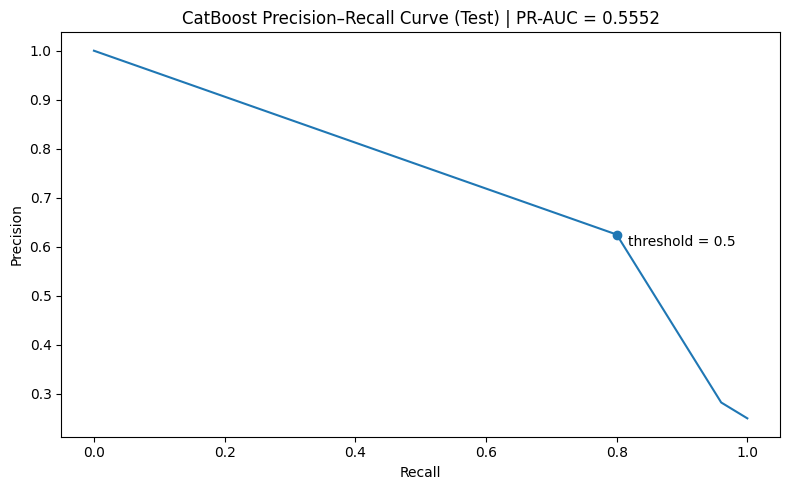

In [20]:
precision, recall, _ = precision_recall_curve(y_test, test_proba_cat)

p_05 = precision_score(y_test, test_pred_cat_05, zero_division = 0)
r_05 = recall_score(y_test, test_pred_cat_05, zero_division = 0)

plt.figure(figsize = (8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'CatBoost Precision–Recall Curve (Test) | PR-AUC = {pr_auc_cat:.4f}')

plt.scatter(r_05, p_05)
plt.annotate('threshold = 0.5', (r_05, p_05), textcoords = 'offset points', xytext = (8, -8))

plt.tight_layout()
plt.savefig(save_dir / 'pr_curve_cat_threshold_0_5.png', dpi = 200)
plt.show()

### Over-/Underfitting Check

In [21]:
train_proba_cat = best_cb.predict_proba(train_pool)[:, 1]
pr_auc_train_cat = average_precision_score(y_tr, train_proba_cat)

pr_auc_test_cat = average_precision_score(y_test, test_proba_cat)

print('Train PR-AUC =', round(pr_auc_train_cat, 4))
print('Test  PR-AUC =', round(pr_auc_test_cat, 4))


train_pred_cat_05 = (train_proba_cat >= 0.5).astype(int)

print('\nTrain report (t = 0.5)')
print(classification_report(y_tr, train_pred_cat_05, digits = 4))

print('\nTest report (t = 0.5)')
print(classification_report(y_test, test_pred_cat_05, digits = 4))

Train PR-AUC = 0.5179
Test  PR-AUC = 0.5552

Train report (t = 0.5)
              precision    recall  f1-score   support

           0     0.8920    0.8690    0.8804       542
           1     0.6302    0.6798    0.6541       178

    accuracy                         0.8222       720
   macro avg     0.7611    0.7744    0.7672       720
weighted avg     0.8273    0.8222    0.8244       720


Test report (t = 0.5)
              precision    recall  f1-score   support

           0     0.9265    0.8400    0.8811        75
           1     0.6250    0.8000    0.7018        25

    accuracy                         0.8300       100
   macro avg     0.7757    0.8200    0.7914       100
weighted avg     0.8511    0.8300    0.8363       100



I check for overfitting by comparing PR-AUC on the training split versus the held-out test set.<br> The PR-AUC is slightly higher on the test set (0.555 vs. 0.518), which suggests no overfitting; instead, the difference could be caused by metric variance due to the small dataset and the sensitivity of PR-AUC to class distribution in small samples.

### Threshold Tuning

In [22]:
def threshold_opt_recall_with_precision(y_true,
                                        y_proba,
                                        precision_min = 0.35,
                                        plot = True,
                                        verbose = True,
                                        title = 'Threshold tuning',
                                        save_dir = None,
                                        save_plot = None):

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    precision_t = precision[1:]
    recall_t = recall[1:]
    thr = thresholds

    mask = precision_t >= precision_min

    if mask.any():
        best_idx = int(np.argmax(recall_t[mask]))
        best_thr = float(thr[mask][best_idx])
    else:
        best_idx = int(np.argmax(recall_t))
        best_thr = float(thr[best_idx])

    best_pred = (y_proba >= best_thr).astype(int)
    best_precision = float(precision_score(y_true, best_pred, zero_division = 0))
    best_recall = float(recall_score(y_true, best_pred, zero_division = 0))

    if plot:

        plt.figure(figsize = (10, 6))
        plt.plot(thr, precision_t, label = 'Precision')
        plt.plot(thr, recall_t, label = 'Recall')
        plt.axvline(best_thr, linestyle = ':', label = f'Best threshold = {best_thr:.4f}')
        plt.axhline(precision_min, linestyle = '--', alpha = 0.7, label = f'Precision ≥ {precision_min:.2f}')
        plt.title(title)
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        if (save_dir is not None) and (save_plot is not None):
            plt.savefig(Path(save_dir) / f'{save_plot}.png', dpi = 200, bbox_inches = 'tight')

        plt.show()

    if verbose:
        print(f'Best threshold = {best_thr:.4f} | Val precision = {best_precision:.4f} | Val recall = {best_recall:.4f}')

    return best_thr, best_precision, best_recall

In [23]:
val_proba_cat = best_cb.predict_proba(valid_pool)[:, 1]

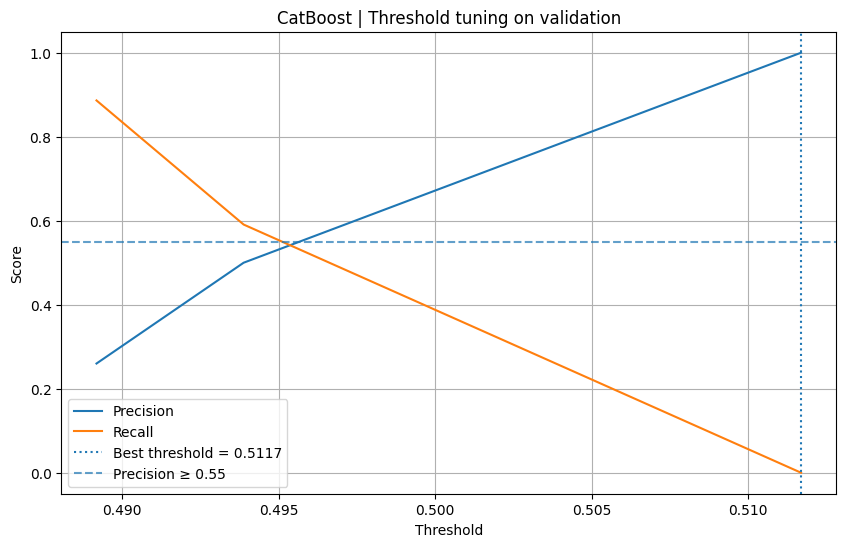

Best threshold = 0.5117 | Val precision = 0.5000 | Val recall = 0.5909


In [38]:
best_t_cat, best_p_cat, best_r_cat = threshold_opt_recall_with_precision(
    y_true = y_val,
    y_proba = val_proba_cat,
    precision_min = 0.55,
    plot = True,
    verbose = True,
    title = 'CatBoost | Threshold tuning on validation',
    save_dir = save_dir,
    save_plot = 'threshold_tuning_catboost'
)

In [39]:
test_pred_cat_tuned = (test_proba_cat >= best_t_cat).astype(int)

print('\nConfusion Matrix (tuned threshold)')
print(confusion_matrix(y_test, test_pred_cat_tuned))

print('\nClassification Report (tuned threshold)')
print(classification_report(y_test, test_pred_cat_tuned, digits = 4))


Confusion Matrix (tuned threshold)
[[63 12]
 [ 5 20]]

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0     0.9265    0.8400    0.8811        75
           1     0.6250    0.8000    0.7018        25

    accuracy                         0.8300       100
   macro avg     0.7757    0.8200    0.7914       100
weighted avg     0.8511    0.8300    0.8363       100



I experimented with different minimum-precision constraints during threshold tuning.<br> Low precision requirements (e.g., 0.30) led to an impractical operating point with excessive false positives.<br> With a realistic precision constraint (0.55), the tuned threshold (~0.51) did not improve test performance over the default threshold, so I keep 0.5.

In [27]:
report_cat_tuned = classification_report(y_test, test_pred_cat_tuned, output_dict = True)
pd.DataFrame(report_cat_tuned).T.round(3).to_csv(save_art / 'classification_report_catboost_tuned.csv', index = True)
print('Saving completed')

Saving completed


In [29]:
def metrics_at_threshold(y_true, y_proba, t):
    y_pred = (y_proba >= t).astype(int)
    return {
        'Threshold' : float(t),
        'Precision' : round(precision_score(y_true, y_pred, zero_division = 0), 3),
        'Recall' : round(recall_score(y_true, y_pred, zero_division = 0), 3),
        'F1' : round(f1_score(y_true, y_pred, zero_division = 0), 3),
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
    }

In [30]:
results = []
results.append({'Model' : 'CatBoost - t = 0.50', **metrics_at_threshold(y_test, test_proba_cat, 0.50)})
results.append({'Model' : f'CatBoost - tuned t = {best_t_cat:.3f}', **metrics_at_threshold(y_test, test_proba_cat, best_t_cat)})

topt_eval_cat = pd.DataFrame(results)
display(topt_eval_cat)

,Model,Threshold,Precision,Recall,F1,Accuracy
0,CatBoost - t = 0.50,0.500000,0.625,0.80,0.702,0.83
1,CatBoost - tuned t = 0.494,0.493885,0.282,0.96,0.436,0.38


In [31]:
topt_eval_cat.to_csv(save_art / 'catboost_threshold_comparison.csv', index = False)
print('Saving completed')

Saving completed


### Model Interpretation

#### Permutation Importance

In [42]:
# Manual permutation importance (PR-AUC) because CatBoost is not sklearn-tag compatible

rng = np.random.RandomState(42)

baseline_proba = best_cb.predict_proba(Xte)[:, 1]
baseline_pr_auc = average_precision_score(y_test, baseline_proba)

n_repeats = 20
rows = []

for col in Xte.columns:

    drops = []

    for _ in range(n_repeats):

        X_perm = Xte.copy()
        X_perm[col] = rng.permutation(X_perm[col].values)

        perm_proba = best_cb.predict_proba(X_perm)[:, 1]
        perm_pr_auc = average_precision_score(y_test, perm_proba)

        drops.append(baseline_pr_auc - perm_pr_auc)

    rows.append({
        'Feature' : col,
        'Importance_mean' : float(np.mean(drops)),
        'Importance_std' : float(np.std(drops))
    })

perm_df = (pd.DataFrame(rows)
           .sort_values('Importance_mean', ascending = False)
           .reset_index(drop = True))

display(perm_df.head(15))


,Feature,Importance_mean,Importance_std
0,incident_severity,0.274243,0.023949
1,months_as_customer,0.000000,0.000000
2,policy_annual_premium,0.000000,0.000000
3,policy_deductable,0.000000,0.000000
4,umbrella_limit,0.000000,0.000000
5,incident_type,0.000000,0.000000
6,collision_type,0.000000,0.000000
7,authorities_contacted,0.000000,0.000000
8,property_damage,0.000000,0.000000
9,total_claim_amount,0.000000,0.000000


In [43]:
perm_df.to_csv(save_art / 'permutation_importance_catboost.csv', index = False)
print('Saving completed')

Saving completed


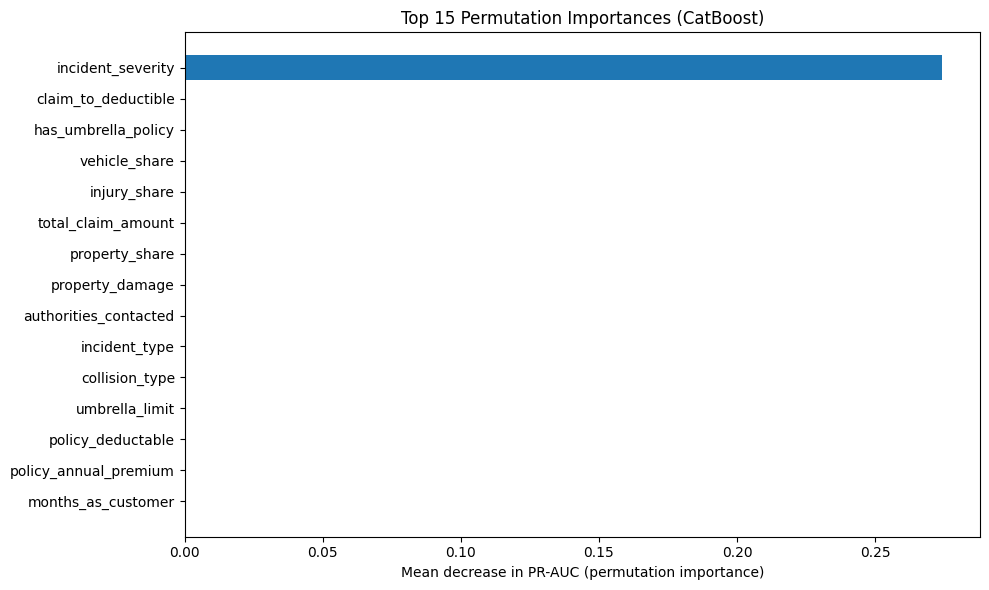

In [44]:
top_n = 15
top_perm = perm_df.head(top_n).sort_values('Importance_mean')

plt.figure(figsize = (10, 6))
plt.barh(top_perm['Feature'], top_perm['Importance_mean'])
plt.xlabel('Mean decrease in PR-AUC (permutation importance)')
plt.title(f'Top {top_n} Permutation Importances (CatBoost)')
plt.tight_layout()
plt.savefig(save_dir / 'permutation_importance_catboost.png', dpi = 200)
plt.show()

I compute permutation importance by measuring the mean decrease in PR-AUC when I randomly permute one feature column while keeping all other columns unchanged.<br> In my results, `incident_severity` dominates: permuting it leads to a substantial PR-AUC drop, which indicates that this feature is the primary driver of the model’s ranking between fraud and non-fraud cases.<br> Most other features show importances close to zero. This does not necessarily mean that these variables are useless; instead, it suggests that (1) their additional signal is weak compared to `incident_severity`, (2) they may be redundant and therefore compensated by correlated features, and (3) PR-AUC on a small test set can be insensitive to small ranking changes.<br> Because my test set is relatively small (n = 100), small probability shifts after permutation may not change the ordering enough to noticeably affect PR-AUC, which can lead to near-zero importances for secondary features.<br> Overall, the permutation results should be interpreted as `“incident_severity` is clearly important”, while the remaining feature importances are less stable and should be cross-checked with SHAP.

#### SHAP

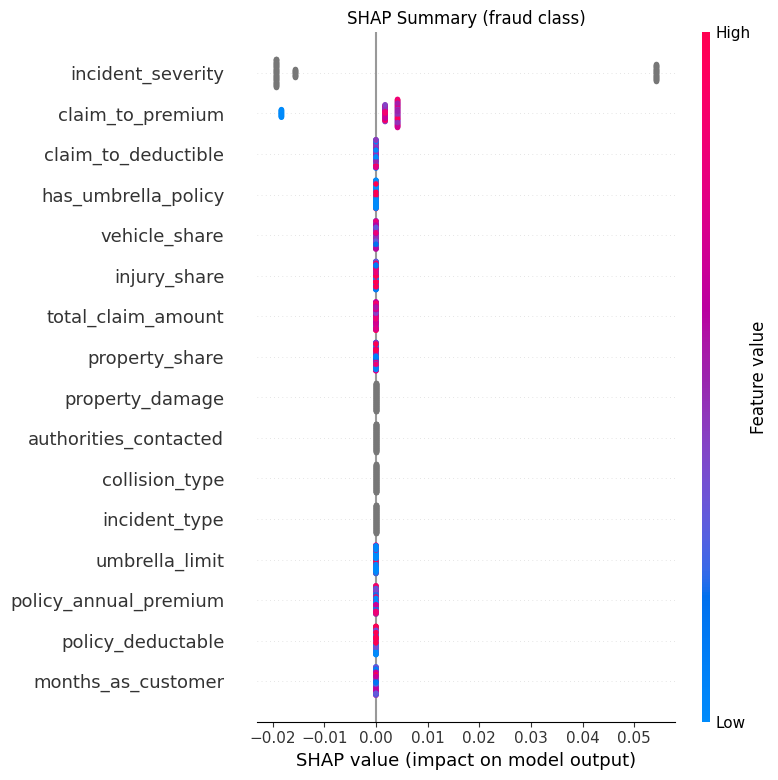

In [40]:
X_shap = Xte.copy()
X_shap_sample = X_shap.sample(n = min(300, len(X_shap)), random_state = 42)

explainer = shap.TreeExplainer(best_cb)
shap_vals = explainer.shap_values(X_shap_sample)

# Depending on SHAP/CatBoost versions, shap_vals can be list or array
shap_vals_pos = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize = (8, 5))
shap.summary_plot(shap_vals_pos, X_shap_sample, feature_names = Xte.columns, show = False)
plt.title('SHAP Summary (fraud class)')
plt.tight_layout()
plt.savefig(save_dir / 'shap_summary_catboost.png', dpi = 200)
plt.show()


I use a SHAP summary plot to understand which features drive CatBoost predictions for the fraud class.<br> The plot shows that `incident_severity` is by far the most influential feature: high severity levels push predictions strongly towards fraud, while low severity levels push them towards non-fraud.<br> All remaining variables have SHAP values concentrated close to zero, indicating that they contribute only marginally to the model output compared to `incident_severity`.<br> This aligns with the permutation importance results and suggests that the model relies heavily on this single feature, while secondary signals from ratio features (e.g., `claim_to_premium` and `claim_to_deductible`) have a much smaller effect.<br> Given the small test set, I interpret the ranking of weaker features cautiously and focus mainly on the consistent finding that incident_severity dominates the decision process.

In [41]:
models_dir = Path('../models/catboost')
models_dir.mkdir(parents = True, exist_ok = True)

model_path = models_dir / 'catboost_model.cbm'
meta_path = models_dir / 'catboost_meta.json'

best_cb.save_model(model_path)

meta_cb = {
    'sklearn_version' : sklearn.__version__,
    'python' : sys.version.split()[0],
    'platform' : platform.platform(),
    'model_type' : 'CatBoostClassifier',
    'threshold_default' : 0.50,
    'threshold_tuned' : float(best_t_cat) if 'best_t_cat' in globals() else None,
    'notes' : 'Model trained with CatBoost randomized_search params + early stopping.'
}

with open(meta_path, 'w') as f:
    json.dump(meta_cb, f, indent = 2)

print('Saved model to:', model_path)
print('Saved metadata to:', meta_path)


Saved model to: ..\models\catboost\catboost_model.cbm
Saved metadata to: ..\models\catboost\catboost_meta.json
